# 02a — Mid-level PLS-DA fusion classifier

**CAC2026 Data Challenge — olive oil musty-defect detection (scored by F1).**

This notebook drives the mid-level data-fusion pipeline on the real challenge data:

```
X_hsms ──PLS-DA(LV)──► T_hsms ┐
X_mir  ──PLS-DA(LV)──► T_mir  ├─ hstack ─► [scale] ─► PLS-DA ─► musty / not-musty
X_uvvis──PLS-DA(LV)──► T_uvvis┘
```

Everything heavy lives in the `olive_oil` package; this notebook only **configures
and runs** it. You set, per block:

1. the **spectral window** (`region`),
2. the **preprocessing recipe** (`steps`), and
3. an optional list of **outlier sample IDs** to discard (default: none).

Then a **systematic coarse-to-fine grid search** tunes the pipeline
hyperparameters (PLS latent variables per block, final PLS-DA latent variables,
and fused-score scaling) under **nested cross-validation** for an honest F1
estimate, before refitting on all calibration data and predicting the test set.

The final classifier here is **PLS-DA**. Sibling notebooks (`02b`, `02c`, ...)
reuse this exact flow with a different `classifier=` and its own grid (SVC, LDA,
QDA, ...).

In [1]:
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
)

# Quiet sklearn's convergence / undefined-metric chatter during the CV sweeps.
warnings.filterwarnings("ignore")

from olive_oil import (
    load_dataset,
    BlockConfig,
    prepare_blocks,
    MidLevelFusionClassifier,
    PLSDAClassifier,
    nested_cv,
    tune_final_model,
    predict_test,
    make_cv,
)
from olive_oil.visualization import plot_spectra

# Resolve the project root whether the notebook runs from Notebooks/ or the root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "Data" / "CAC2026_Data_challenge.xlsx"
DATA_PATH

WindowsPath('C:/Users/SamdGuizani/OneDrive/Documents/Data Science & Coding/2026-Olive Oil Classification (CAC 2026)/CAC-2026_Data-Challenge_Olive-Oil-Sensory-Defects-Detection-Using-Chemometrics/Data/CAC2026_Data_challenge.xlsx')

## 1. Load the data

`load_dataset` reads all eight sheets. Spectral sheets keep their replicates;
`prepare_blocks` (below) averages them per sample.

In [2]:
raw = load_dataset(DATA_PATH)
labels = raw["labels"]
print("Calibration samples:", labels.shape[0])
print("Class balance (0 = not musty, 1 = musty):",
      labels["label"].value_counts().sort_index().to_dict())
print("Musty prevalence:", round(labels["label"].mean(), 3))

Calibration samples: 220
Class balance (0 = not musty, 1 = musty): {0: 144, 1: 76}
Musty prevalence: 0.345


## 2. Configure the blocks

Each block gets a **spectral window** and a **preprocessing recipe**. The defaults
below follow the reference paper (Borràs et al., 2016) — change the `region`
bounds and `steps` freely to explore.

**Steps** are applied in order, after region selection. Available steps:
`row_profile`, `log`, `snv`, `savgol_derivative`, `mean_center`. Use a
`(name, kwargs)` tuple to pass parameters, e.g.
`("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 3})`.

> **Leakage note:** the per-sample steps (`row_profile`, `log`, `snv`,
> `savgol_derivative`) are computed independently per spectrum. `mean_center` is
> fit on the calibration set and the same column means are reused on the test set.
> The fusion PLS also centres internally, so `mean_center` is optional here — kept
> to mirror the paper.

In [3]:
# Per-block spectral window + preprocessing recipe.
configs = {
    "hsms": BlockConfig(
        region=(100, 125),
        steps=["row_profile", "log", "mean_center"],
    ),
    "mir": BlockConfig(
        region=(1500, 700),
        steps=["snv",
               ("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 6}),
               "mean_center"],
    ),
    "uvvis": BlockConfig(
        region=(300, 1000),
        steps=["snv",
               ("savgol_derivative", {"deriv": 1, "polyorder": 2, "half_window": 6}),
               "mean_center"],
    ),
}

# Calibration sample IDs to discard as outliers (default: none).
# Outlier removal did not improve the honest F1, so we keep all calibration data.
# A sample listed here is removed from EVERY block (cross-block discard rule).
outliers = []

data = prepare_blocks(raw, configs, outliers=outliers)
print("Discarded outliers:", data.discarded_ids or "none")
print("Block order:", data.block_names)
data.summary()

Discarded outliers: none
Block order: ['hsms', 'mir', 'uvvis']


,n_variables,axis_min,axis_max,n_train,n_test
block,,,,,
hsms,26,100.00000,125.000000,220,24
mir,208,700.04498,1498.443334,220,24
uvvis,701,300.00000,1000.000000,220,24


### Sanity-check the preprocessed spectra (optional)

Plot one block after preprocessing, coloured by class, to confirm the window and
recipe look sensible.

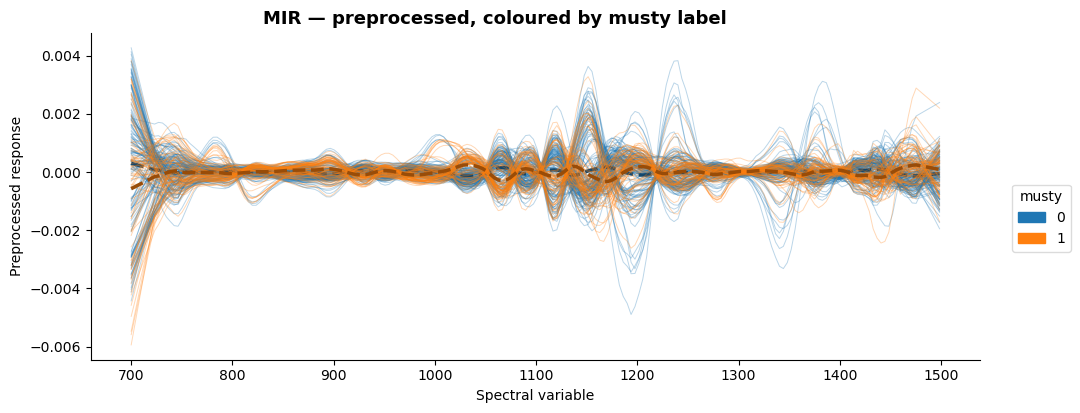

In [4]:
block = "mir"  # try "hsms" / "uvvis" too
i = data.block_names.index(block)
spectra = (data.X_train[i], data.axes[block], data.train_ids)
label_meta = raw["labels"].rename(columns={"label": "musty"})

g = plot_spectra(
    spectra, metadata=label_meta, color_by="musty",
    xlabel="Spectral variable", ylabel="Preprocessed response",
    title=f"{block.upper()} — preprocessed, coloured by musty label",
)

## 3. Build the coarse hyperparameter grid

We search the pipeline hyperparameters **jointly** (the whole point of this
project versus the paper's per-block tuning):

| Hyperparameter | Meaning | Coarse range |
|---|---|---|
| `n_components_list[0]` (hsms) | block PLS-DA latent variables | `4, 6, 8, 10, 12` |
| `n_components_list[1]` (mir)  | block PLS-DA latent variables | `9, 12, 15, 18, 21, 24` |
| `n_components_list[2]` (uvvis)| block PLS-DA latent variables | `3, 6, 9, 12` |
| `classifier__n_components`    | **final** PLS-DA LVs on fused scores | `1, 2, 3, 4, 5, 6, 7` |
| `scale_fused`                 | StandardScale fused scores | `True, False` |

`n_components_list` is one tuple parameter, so a thorough search needs the
**Cartesian product** of the per-block ranges, built into a list of tuples.

> **Validity constraint:** the final PLS-DA runs on a fused matrix whose width =
> sum of the three block LVs, so `classifier__n_components` must be ≤ that sum.
> With block LVs ≥ 2 each (min sum = 8), a final LV up to 5 is always valid — the
> grid is valid *by construction*, no failed fits.

In [5]:
# Per-block latent-variable ranges (coarse). MIR and the final PLS-DA were both
# pinned at the upper edge last run, so we push those two ceilings higher; HS-MS
# and UV-vis had already converged in the interior.
LV_HSMS  = (4, 6, 8, 10, 12)
LV_MIR   = (9, 12, 15, 18, 21, 24)
LV_UVVIS = (3, 6, 9, 12)
LV_FINAL = (1, 2, 3, 4, 5, 6, 7)

# Cartesian product -> list of (hsms, mir, uvvis) tuples (tuples, for GridSearchCV).
component_grid = [tuple(t) for t in product(LV_HSMS, LV_MIR, LV_UVVIS)]

param_grid = {
    "n_components_list": component_grid,
    "classifier__n_components": list(LV_FINAL),
    "scale_fused": [True, False],
}

n_configs = len(component_grid) * len(LV_FINAL) * 2
min_block_sum = min(sum(t) for t in component_grid)
assert max(LV_FINAL) <= min_block_sum, "final LV exceeds smallest fused width"
print(f"Component tuples : {len(component_grid)}")
print(f"Total configs    : {n_configs}")
print(f"Inner fits/outer : {n_configs} x 3 folds = {n_configs*3}")
print(f"Nested fits total: ~{n_configs*3*5} (5 outer folds)  -> expect a few minutes with n_jobs=-1")

Component tuples : 120
Total configs    : 1680
Inner fits/outer : 1680 x 3 folds = 5040
Nested fits total: ~25200 (5 outer folds)  -> expect a few minutes with n_jobs=-1


## 4. Define the model

PLS-DA as the final classifier on the fused scores. `scale_fused` is searched, so
its value here is just a placeholder the grid overrides.

In [6]:
model = MidLevelFusionClassifier(
    classifier=PLSDAClassifier(),   # swap here for 02b/02c (SVC, LDA, QDA, ...)
    scale_fused=True,
)

## 5. Nested cross-validation — the honest F1 estimate

Inner `GridSearchCV` (3-fold) tunes the **whole coarse grid** on each outer
training split; outer `cross_validate` (5-fold) scores F1/precision/recall on the
held-out outer fold. The **outer test mean ± std** is the unbiased estimate to
report.

> The inner grid here is the *same* grid used for the final fit in §6 — that
> consistency is what makes this an honest estimate of the procedure we ship.

In [7]:
nested = nested_cv(
    model, param_grid,
    data.train_blocks(), data.y,
    outer_cv=make_cv(5, random_state=0),
    inner_cv=make_cv(3, random_state=1),
)

print("Outer-fold performance (mean ± std):")
display(nested["summary"].round(3))

f1 = nested["raw"]["test_f1"]
coarse_nested_f1 = f1.mean()
print("Per-fold F1:", np.round(f1, 3))
print(f"Nested-CV F1 (coarse grid): {f1.mean():.3f} +/- {f1.std():.3f}")
print("\nWinning hyperparameters per outer fold:")
for k, p in enumerate(nested["best_params"]):
    print(f"  fold {k}: {p}")

Outer-fold performance (mean ± std):


,test_mean,test_std,train_mean,train_std
metric,,,,
f1,0.765,0.052,0.924,0.043
precision,0.801,0.043,0.957,0.028
recall,0.737,0.085,0.895,0.057


Per-fold F1: [0.759 0.812 0.786 0.667 0.8  ]
Nested-CV F1 (coarse grid): 0.765 +/- 0.052

Winning hyperparameters per outer fold:
  fold 0: {'classifier__n_components': 5, 'n_components_list': (10, 9, 12), 'scale_fused': True}
  fold 1: {'classifier__n_components': 5, 'n_components_list': (4, 12, 9), 'scale_fused': True}
  fold 2: {'classifier__n_components': 1, 'n_components_list': (4, 9, 9), 'scale_fused': True}
  fold 3: {'classifier__n_components': 5, 'n_components_list': (12, 9, 12), 'scale_fused': True}
  fold 4: {'classifier__n_components': 4, 'n_components_list': (4, 9, 9), 'scale_fused': True}


## 6. Refit on all calibration data (coarse grid)

A single `GridSearchCV` over the full calibration set selects the final
hyperparameters and refits the model. Its `best_score_` is the inner-CV F1 of the
winner — optimistic versus the nested estimate above, which stays the number to
report.

In [8]:
search = tune_final_model(
    model, param_grid,
    data.train_blocks(), data.y,
    cv=make_cv(5, random_state=0),
)
print("Best hyperparameters:", search.best_params_)
print("Best inner-CV F1     :", round(search.best_score_, 3))

Best hyperparameters: {'classifier__n_components': 6, 'n_components_list': (4, 18, 9), 'scale_fused': True}
Best inner-CV F1     : 0.787


## 7. Explore the search landscape

The grid search gives us the full `cv_results_`, not just the winner. Inspecting
it tells us *where* the good region is and how sharp the optimum is — which guides
the fine grid in §8.

In [9]:
res = pd.DataFrame(search.cv_results_)
lv = pd.DataFrame(res["param_n_components_list"].tolist(),
                  index=res.index, columns=["lv_hsms", "lv_mir", "lv_uvvis"])
res = pd.concat([res, lv], axis=1)
res["lv_final"] = res["param_classifier__n_components"].astype(int)
res["scale_fused"] = res["param_scale_fused"]

show_cols = ["lv_hsms", "lv_mir", "lv_uvvis", "lv_final", "scale_fused",
             "mean_test_score", "std_test_score", "rank_test_score"]
print("Top 15 configurations by mean CV F1:")
display(res.sort_values("rank_test_score")[show_cols].head(15).round(3).reset_index(drop=True))

Top 15 configurations by mean CV F1:


,lv_hsms,lv_mir,lv_uvvis,lv_final,scale_fused,mean_test_score,std_test_score,rank_test_score
0,4,18,9,6,True,0.787,0.033,1
1,4,18,9,6,False,0.787,0.033,1
2,8,18,9,6,False,0.786,0.015,3
3,8,18,9,6,True,0.786,0.015,3
4,8,18,9,5,False,0.786,0.019,5
5,8,18,9,5,True,0.786,0.019,5
6,6,18,9,7,False,0.785,0.020,7
7,6,18,9,7,True,0.785,0.020,7
8,4,18,9,4,False,0.783,0.036,9
9,4,18,9,4,True,0.783,0.036,9


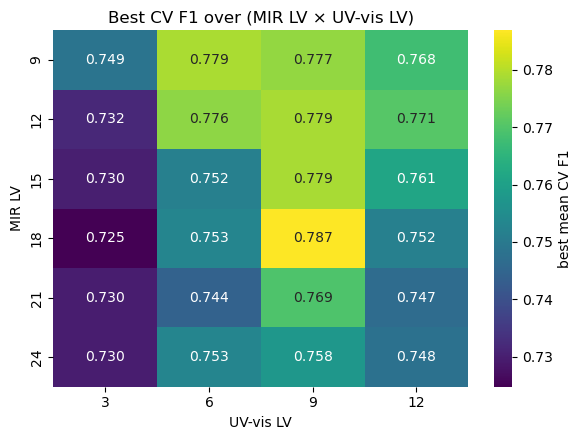

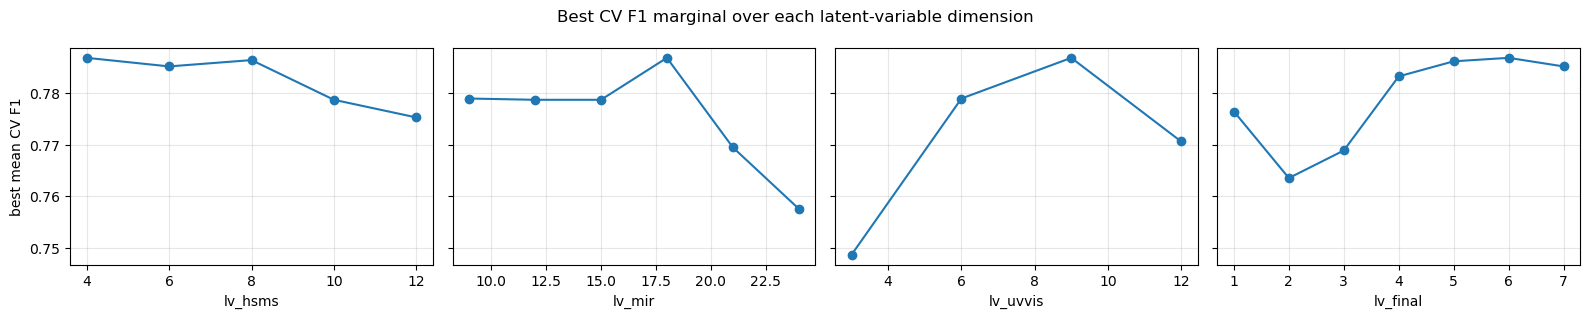

In [10]:
# (a) Heatmap: best CV F1 for each (mir, uvvis) LV pair (max over the other params).
piv = res.pivot_table(index="lv_mir", columns="lv_uvvis",
                      values="mean_test_score", aggfunc="max")
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="viridis", ax=ax,
            cbar_kws={"label": "best mean CV F1"})
ax.set_title("Best CV F1 over (MIR LV × UV-vis LV)")
ax.set_xlabel("UV-vis LV"); ax.set_ylabel("MIR LV")
plt.tight_layout(); plt.show()

# (b) Marginal: best CV F1 against each LV dimension (max over all other params).
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2), sharey=True)
for ax, col in zip(axes, ["lv_hsms", "lv_mir", "lv_uvvis", "lv_final"]):
    gmax = res.groupby(col)["mean_test_score"].max()
    ax.plot(gmax.index, gmax.values, "o-")
    ax.set_xlabel(col); ax.grid(alpha=0.3)
axes[0].set_ylabel("best mean CV F1")
fig.suptitle("Best CV F1 marginal over each latent-variable dimension")
plt.tight_layout(); plt.show()

## 8. Fine grid around the coarse winner (optional refinement)

Zoom into a ±2-LV neighbourhood of the coarse winner (the coarse grid now steps
by 3, so ±2 fills the gaps between coarse points). To keep the reported F1
**honest**, we re-run nested CV on the fine grid too (not just the optimistic
refit score) and compare it against the coarse estimate before choosing the model
to deploy.

In [11]:
def neighbours(value, lo, hi, span=2):
    return sorted({max(lo, min(hi, value + d)) for d in range(-span, span + 1)})

best = search.best_params_
b_hsms, b_mir, b_uvvis = best["n_components_list"]

fine_components = [
    tuple(t) for t in product(
        neighbours(b_hsms, 1, 14),
        neighbours(b_mir, 1, 28),
        neighbours(b_uvvis, 1, 18),
    )
]
fine_min_sum = min(sum(t) for t in fine_components)
fine_final = [v for v in neighbours(best["classifier__n_components"], 1, 10) if v <= fine_min_sum]

fine_grid = {
    "n_components_list": fine_components,
    "classifier__n_components": fine_final,
    "scale_fused": [best["scale_fused"]],   # lock to the coarse-chosen value
}
print("Fine component tuples:", fine_components)
print("Fine final LVs       :", fine_final)
print("Fine configs         :", len(fine_components) * len(fine_final))

Fine component tuples: [(2, 16, 7), (2, 16, 8), (2, 16, 9), (2, 16, 10), (2, 16, 11), (2, 17, 7), (2, 17, 8), (2, 17, 9), (2, 17, 10), (2, 17, 11), (2, 18, 7), (2, 18, 8), (2, 18, 9), (2, 18, 10), (2, 18, 11), (2, 19, 7), (2, 19, 8), (2, 19, 9), (2, 19, 10), (2, 19, 11), (2, 20, 7), (2, 20, 8), (2, 20, 9), (2, 20, 10), (2, 20, 11), (3, 16, 7), (3, 16, 8), (3, 16, 9), (3, 16, 10), (3, 16, 11), (3, 17, 7), (3, 17, 8), (3, 17, 9), (3, 17, 10), (3, 17, 11), (3, 18, 7), (3, 18, 8), (3, 18, 9), (3, 18, 10), (3, 18, 11), (3, 19, 7), (3, 19, 8), (3, 19, 9), (3, 19, 10), (3, 19, 11), (3, 20, 7), (3, 20, 8), (3, 20, 9), (3, 20, 10), (3, 20, 11), (4, 16, 7), (4, 16, 8), (4, 16, 9), (4, 16, 10), (4, 16, 11), (4, 17, 7), (4, 17, 8), (4, 17, 9), (4, 17, 10), (4, 17, 11), (4, 18, 7), (4, 18, 8), (4, 18, 9), (4, 18, 10), (4, 18, 11), (4, 19, 7), (4, 19, 8), (4, 19, 9), (4, 19, 10), (4, 19, 11), (4, 20, 7), (4, 20, 8), (4, 20, 9), (4, 20, 10), (4, 20, 11), (5, 16, 7), (5, 16, 8), (5, 16, 9), (5, 16, 10

In [12]:
nested_fine = nested_cv(
    model, fine_grid,
    data.train_blocks(), data.y,
    outer_cv=make_cv(5, random_state=0),
    inner_cv=make_cv(3, random_state=1),
)
fine_nested_f1 = nested_fine["raw"]["test_f1"].mean()

fine_search = tune_final_model(
    model, fine_grid, data.train_blocks(), data.y, cv=make_cv(5, random_state=0),
)

print(f"Coarse nested-CV F1: {coarse_nested_f1:.3f}")
print(f"Fine   nested-CV F1: {fine_nested_f1:.3f}")
print("Fine best params   :", fine_search.best_params_)

Coarse nested-CV F1: 0.765
Fine   nested-CV F1: 0.727
Fine best params   : {'classifier__n_components': 8, 'n_components_list': (4, 18, 9), 'scale_fused': True}


## 9. Deploy the best model

Pick whichever grid gave the better **honest (nested)** F1; its `tune_final_model`
search is already refit on all calibration data.

In [13]:
if fine_nested_f1 >= coarse_nested_f1:
    final_search, tag, headline_f1 = fine_search, "fine", fine_nested_f1
else:
    final_search, tag, headline_f1 = search, "coarse", coarse_nested_f1

print(f"Deploying the {tag}-grid model "
      f"(nested-CV F1 = {headline_f1:.3f}; params = {final_search.best_params_})")

Deploying the coarse-grid model (nested-CV F1 = 0.765; params = {'classifier__n_components': 6, 'n_components_list': (4, 18, 9), 'scale_fused': True})


## 10. Training-set fit of the deployed model

Scores of the deployed model on the **calibration set it was fitted on**
(resubstitution): F1, Precision, Recall and Inaccuracy (% misclassified).

> These are **optimistic** — the model has seen these samples. The honest
> generalization estimate stays the nested-CV F1 (§5). The gap between the two is
> a useful overfitting diagnostic.

In [14]:
y_train_pred = final_search.predict(data.train_blocks())

train_scores = pd.DataFrame(
    {"train": [
        f1_score(data.y, y_train_pred),
        precision_score(data.y, y_train_pred),
        recall_score(data.y, y_train_pred),
        100.0 * (1.0 - accuracy_score(data.y, y_train_pred)),
    ]},
    index=["F1", "Precision", "Recall", "Inaccuracy (%)"],
)
print(f"Deployed model train-set fit (n = {len(data.y)} samples):")
display(train_scores.round(3))
print(f"For reference — honest nested-CV F1: {headline_f1:.3f}")

Deployed model train-set fit (n = 220 samples):


,train
F1,0.918
Precision,0.957
Recall,0.882
Inaccuracy (%),5.455


For reference — honest nested-CV F1: 0.765


## 11. Predict the test set

Predict the 24 unlabeled test samples with the deployed model and save a
submission CSV.

In [15]:
predictions = predict_test(final_search, data.test_blocks(), data.test_ids)
print("Predicted test balance:",
      predictions["prediction"].value_counts().sort_index().to_dict())

out_path = PROJECT_ROOT / "Data" / "predictions_02a_PLSDA.csv"
predictions.to_csv(out_path, index=False)
print("Saved:", out_path)
predictions

Predicted test balance: {0: 16, 1: 8}
Saved: C:\Users\SamdGuizani\OneDrive\Documents\Data Science & Coding\2026-Olive Oil Classification (CAC 2026)\CAC-2026_Data-Challenge_Olive-Oil-Sensory-Defects-Detection-Using-Chemometrics\Data\predictions_02a_PLSDA.csv


,sample_id,prediction,proba_musty
0,1,1,0.812693
1,2,0,0.098327
2,3,1,0.707104
3,4,0,0.271503
4,5,0,0.000000
5,6,0,0.000000
6,7,0,0.286917
7,8,1,0.930596
8,9,0,0.228593
9,10,0,0.139643


## Next steps

- **Try other classifiers (02b, 02c, ...):** copy this notebook and change only
  the `classifier=` and the grid. The fusion code and search flow are untouched.
  - `SVC(kernel="rbf", probability=True)` with `classifier__C`, `classifier__gamma`
  - `LinearDiscriminantAnalysis()` / `QuadraticDiscriminantAnalysis()`
  - `RandomForestClassifier(random_state=0)` with `classifier__n_estimators`, `classifier__max_depth`
- **Tune windows / recipes** in §2 and re-run — the whole flow is config-driven.
- **Feed real outliers** into the `outliers` list once flagged by the PCA T²/Q
  detector (`olive_oil.outliers`).
- **Go denser** by widening the §3 ranges; if it gets slow, switch the inner
  search to `HalvingGridSearchCV` (successive halving) — ask and I'll wire it in.